# Final Project Report: Galaxy Zoo Morphology Prediction with CNN

**Kaggle Competition:** [Galaxy Zoo - The Galaxy Challenge](https://www.kaggle.com/c/galaxy-zoo-the-galaxy-challenge)

Predict 37 morphology probability scores for ~61,000 labeled galaxy images using a CNN + FCN regression model. Each output column represents the fraction of volunteers who selected a particular morphology answer in a hierarchical survey. The competition metric is **RMSE** averaged across all 37 columns.

**Names:** Byeongguk Lee and Akhil Samrat

**AI Use Acknowledgement:** Claude (claude.ai/code) and ChatGPT (chatgpt.com) was used to assist with notebook structure and implementation.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Using device: {device}')

Using device: cuda


## Prepare Data

**Requirements:**
- Download the Galaxy Zoo dataset from [Kaggle](https://www.kaggle.com/c/galaxy-zoo-the-galaxy-challenge/data) (requires Kaggle account + competition join)
  ```
  kaggle competitions download -c galaxy-zoo-the-galaxy-challenge
  ```
- Place files in the following structure within `final_project/`:
  ```
  data/
    images_training_rev1/       # 61,578 training images (.jpg, 424×424 RGB)
    images_test_rev1/           # 79,975 test images (.jpg, 424×424 RGB)
    training_solutions_rev1.csv # GalaxyID + 37 float probability columns
  ```
- Images are center-cropped to 207×207 to remove sky borders, then resized to 64×64
- Training augmentations: random horizontal/vertical flips + random rotation (galaxies have no preferred orientation)
- 90% train / 10% validation split using a fixed random seed

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [3]:
import os
import zipfile
import kagglehub
import pandas as pd

# 1. Download the main competition dataset
downloaded_path = kagglehub.competition_download('galaxy-zoo-the-galaxy-challenge')
print(f"Main archive downloaded and extracted to: {downloaded_path}")

# 2. Define target workspace directory in Colab's local scratch disk
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

# 3. Unzip the nested zip files into DATA_DIR
nested_zips = ['training_solutions_rev1.zip', 'images_training_rev1.zip', 'images_test_rev1.zip']

for zip_name in nested_zips:
    zip_path = os.path.join(downloaded_path, zip_name)
    if os.path.exists(zip_path):
        print(f"Extracting nested file: {zip_name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)
    else:
        print(f"Warning: Could not find {zip_name} in the downloaded cache.")

print("All extractions completed successfully.")



TRAIN_DIR = os.path.join(DATA_DIR, 'images_training_rev1')
TEST_DIR  = os.path.join(DATA_DIR, 'images_test_rev1')
CSV_PATH  = os.path.join(DATA_DIR, 'training_solutions_rev1.csv')

labels_df     = pd.read_csv(CSV_PATH)
label_columns = [c for c in labels_df.columns if c != 'GalaxyID']
NUM_OUTPUTS   = len(label_columns)
IMG_SIZE      = 64

print(f'\nTraining samples : {len(labels_df)}')
print(f'Output columns   : {NUM_OUTPUTS}')
print(labels_df.head())

100%|██████████| 1.77G/1.77G [00:20<00:00, 92.5MB/s]

Extracting files...


Main archive downloaded and extracted to: /root/.cache/kagglehub/competitions/galaxy-zoo-the-galaxy-challenge
Extracting nested file: training_solutions_rev1.zip...
Extracting nested file: images_training_rev1.zip...
Extracting nested file: images_test_rev1.zip...
All extractions completed successfully.

Training samples : 61578
Output columns   : 37
   GalaxyID  Class1.1  Class1.2  Class1.3  Class2.1  Class2.2  Class3.1  \
0    100008  0.383147  0.616853  0.000000  0.000000  0.616853  0.038452   
1    100023  0.327001  0.663777  0.009222  0.031178  0.632599  0.467370   
2    100053  0.765717  0.177352  0.056931  0.000000  0.177352  0.000000   
3    100078  0.693377  0.238564  0.068059  0.000000  0.238564  0.109493   
4    100090  0.933839  0.000000  0.066161  0.000000  0.000000  0.000000   

   Class3.2  Class4.1  Class4.2  ...  Class9.3  Class10.1  Class10.2  \
0  0.578401  0.418398  0.198455  ...  0.000000   0.279952   0.138445   
1  0.165229  0.591328  0.041271  ...  0.018764   0.0

In [4]:
# Custom dataset class for loading Galaxy Zoo images and labels
class GalaxyDataset(Dataset):

    def __init__(self, image_dir, labels_df=None, transform=None):
        # Store image directory and image transformations
        self.image_dir = image_dir
        self.transform = transform

        # Training/validation mode: load galaxy IDs and labels
        if labels_df is not None:
            self.galaxy_ids = labels_df['GalaxyID'].values
            self.labels = labels_df[label_columns].values.astype(np.float32)

        # Test mode: load only galaxy IDs from image filenames
        else:
            fnames = sorted(f for f in os.listdir(image_dir) if f.endswith('.jpg'))
            self.galaxy_ids = np.array([int(f.split('.')[0]) for f in fnames])
            self.labels = None

    def __len__(self):
        # Return total number of galaxy samples
        return len(self.galaxy_ids)

    def __getitem__(self, idx):
        # Load image corresponding to the requested galaxy ID
        img_path = os.path.join(self.image_dir, f'{self.galaxy_ids[idx]}.jpg')
        image = Image.open(img_path).convert('RGB')

        # Apply preprocessing and augmentation transforms
        if self.transform:
            image = self.transform(image)

        # Return image and labels for training/validation
        if self.labels is not None:
            return image, torch.tensor(self.labels[idx])

        # Return image and galaxy ID for test predictions
        return image, int(self.galaxy_ids[idx])

In [5]:
# Shuffle dataset and create 90/10 train-validation split
shuffled_df = labels_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Compute validation set size
val_size = int(0.1 * len(shuffled_df))

# Separate shuffled labels into training and validation dataframes
train_df = shuffled_df.iloc[val_size:].reset_index(drop=True)
val_df   = shuffled_df.iloc[:val_size].reset_index(drop=True)

# Training image preprocessing and augmentation pipeline
train_transform = transforms.Compose([
    transforms.CenterCrop(207),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Data augmentation for improved rotation and reflection invariance
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),

    # Convert image to tensor and normalize using ImageNet statistics
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Validation/test preprocessing without augmentation
val_transform = transforms.Compose([
    transforms.CenterCrop(207),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Create training, validation, and test datasets
train_dataset = GalaxyDataset(TRAIN_DIR, labels_df=train_df, transform=train_transform)
val_dataset   = GalaxyDataset(TRAIN_DIR, labels_df=val_df,   transform=val_transform)
test_dataset  = GalaxyDataset(TEST_DIR,                      transform=val_transform)

# Print dataset sizes
print(f'Train : {len(train_dataset)} samples')
print(f'Val   : {len(val_dataset)} samples')
print(f'Test  : {len(test_dataset)} samples')

Train : 55421 samples
Val   : 6157 samples
Test  : 79975 samples


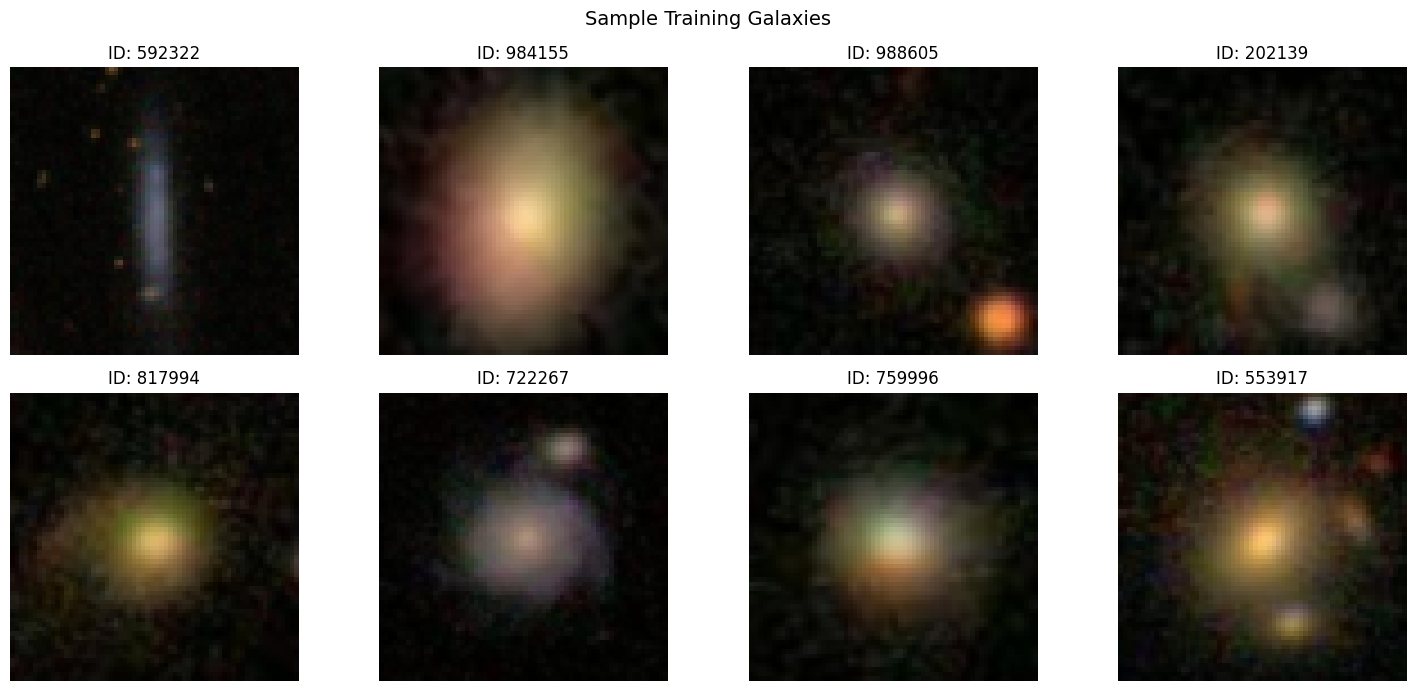

In [6]:
# Display 8 sample training galaxies (raw images before transforms)
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    galaxy_id = train_df.iloc[i]['GalaxyID']
    img = Image.open(os.path.join(TRAIN_DIR, f'{int(galaxy_id)}.jpg')).convert('RGB')
    img = transforms.CenterCrop(207)(img)
    img = transforms.Resize((IMG_SIZE, IMG_SIZE))(img)
    ax.imshow(img)
    ax.set_title(f'ID: {int(galaxy_id)}')
    ax.axis('off')
plt.suptitle('Sample Training Galaxies', fontsize=14)
plt.tight_layout()

## Define Model

**Architecture (CNN + FCN):**
- **Input:** (B, 3, 64, 64) — 3-channel RGB galaxy images
- **CNN backbone:** 4 convolutional blocks, each Conv2d → BatchNorm2d → ReLU → MaxPool2d(2,2)
  - Channels: 3 → 32 → 64 → 128 → 256
  - Spatial size after 4 poolings on 64×64 input: 4×4
- **Flatten:** 256 × 4 × 4 = 4096 features
- **FCN head:** Linear(4096→512) → Dropout(0.5) → Linear(512→256) → Dropout(0.5) → Linear(256→37)
- **Output activation:** Sigmoid — all 37 predictions are probabilities in [0, 1]
- **Loss:** MSELoss (RMSE reported for interpretability)

**Requirements:**
- Batch normalization after each conv layer stabilizes training
- Dropout(0.5) on FC layers prevents overfitting on the large image dataset
- Sigmoid ensures outputs stay in [0, 1] consistent with the probability target labels

In [7]:
# Convolutional neural network for Galaxy Zoo image classification
class GalaxyZooCNN(torch.nn.Module):
    def __init__(self, img_size=64, num_outputs=37):
        # Initialize parent PyTorch module
        super(GalaxyZooCNN, self).__init__()

        # Convolutional feature extraction layers
        self.conv1 = torch.nn.Conv2d(3,   32,  kernel_size=3, padding=1)
        self.bn1   = torch.nn.BatchNorm2d(32)
        self.conv2 = torch.nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.bn2   = torch.nn.BatchNorm2d(64)
        self.conv3 = torch.nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3   = torch.nn.BatchNorm2d(128)
        self.conv4 = torch.nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4   = torch.nn.BatchNorm2d(256)

        # Shared activation, pooling, and regularization layers
        self.pool    = torch.nn.MaxPool2d(2, 2)
        self.relu    = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.5)

        # Compute flattened feature size after four pooling layers
        feature_size = 256 * (img_size // 16) * (img_size // 16)

        # Fully connected classifier layers
        self.fc1 = torch.nn.Linear(feature_size, 512)
        self.fc2 = torch.nn.Linear(512, 256)
        self.fc3 = torch.nn.Linear(256, num_outputs)

    def forward(self, x):
        # (B, 3, 64, 64) -> (B, 32, 32, 32)
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # (B, 32, 32, 32) -> (B, 64, 16, 16)
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # (B, 64, 16, 16) -> (B, 128, 8, 8)
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        # (B, 128, 8, 8) -> (B, 256, 4, 4)
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        # (B, 256, 4, 4) -> (B, 4096)
        x = x.view(x.size(0), -1)

        # Fully connected layers with dropout
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))

        # Sigmoid outputs probabilities for each Galaxy Zoo label
        x = torch.sigmoid(self.fc3(x))
        return x

In [8]:
# Create CNN model and move it to the selected device (CPU/GPU)
model = GalaxyZooCNN(img_size=IMG_SIZE, num_outputs=NUM_OUTPUTS).to(device)

# Count total number of trainable model parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Display parameter count and model architecture
print(f'Trainable parameters: {total_params:,}')
print(model)

Trainable parameters: 2,627,877
GalaxyZooCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(

## Select Hyperparameters

**Requirements:**
- `learning_rate = 1e-3`: Adam default; good starting point for image regression
- `weight_decay = 1e-4`: L2 regularization to reduce overfitting
- `epochs = 30`: adjust up or down based on validation RMSE convergence
- `batchsize = 64`: balance between GPU memory and gradient quality
- **Scheduler:** `ReduceLROnPlateau` — halves LR when validation RMSE stops improving for 3 epochs

In [9]:
# Define training hyperparameters
learning_rate = 1e-3
weight_decay  = 1e-4
epochs        = 30
batchsize     = 64

# Mean squared error loss for probability regression targets
loss_func = torch.nn.MSELoss()

# Adam optimizer with L2 regularization
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Reduce learning rate when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

## Identify Tracked Values

- **`train_loss_list`**: MSE loss recorded after every training batch
- **`val_rmse_list`**: RMSE on the full validation set recorded after every epoch

In [10]:
train_loss_list = []   # MSE per batch
val_rmse_list   = []   # RMSE per epoch

## Train Model

**Requirements:**
- Each epoch: iterate over `train_loader` → forward → MSELoss → backward → Adam step
- After each epoch: compute RMSE on `val_loader` (no gradients), step the LR scheduler
- Save model weights to `best_model.pth` whenever validation RMSE improves
- `num_workers=4` for parallel image loading (set to 0 if running on Windows or in Colab)

In [11]:
# Import progress bar utility
import tqdm

# Enable pinned memory when using a GPU
pin = device.type == 'cuda'

# Create dataloaders for training and validation datasets
train_loader = DataLoader(
    train_dataset,
    batch_size=batchsize,
    shuffle=True,
    num_workers=4,
    pin_memory=pin
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batchsize,
    shuffle=False,
    num_workers=4,
    pin_memory=pin
)

# Track the best validation RMSE achieved during training
best_val_rmse = float('inf')

# Main training loop
for epoch in tqdm.trange(epochs, desc='Epochs'):

    # --- Training ---
    model.train()

    # Iterate through training batches
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass, loss computation, and backpropagation
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = loss_func(preds, y_batch)
        loss.backward()
        optimizer.step()

        # Store training loss for later visualization
        train_loss_list.append(loss.item())

    # --- Validation ---
    model.eval()

    # Collect squared prediction errors across validation set
    sq_errors = []

    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)

            preds = model(X_val)
            sq_err = (preds - y_val) ** 2
            sq_errors.append(sq_err.cpu().numpy())

    # Compute overall validation RMSE
    val_rmse = float(np.sqrt(np.concatenate(sq_errors, axis=0).mean()))
    val_rmse_list.append(val_rmse)

    # Update learning rate scheduler using validation RMSE
    scheduler.step(val_rmse)

    # Save model weights if validation performance improves
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), 'best_model.pth')

# Print best validation RMSE achieved during training
print(f'\nBest validation RMSE: {best_val_rmse:.5f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epochs:   0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationalit


Best validation RMSE: 0.10162


## Visualize & Evaluate Model

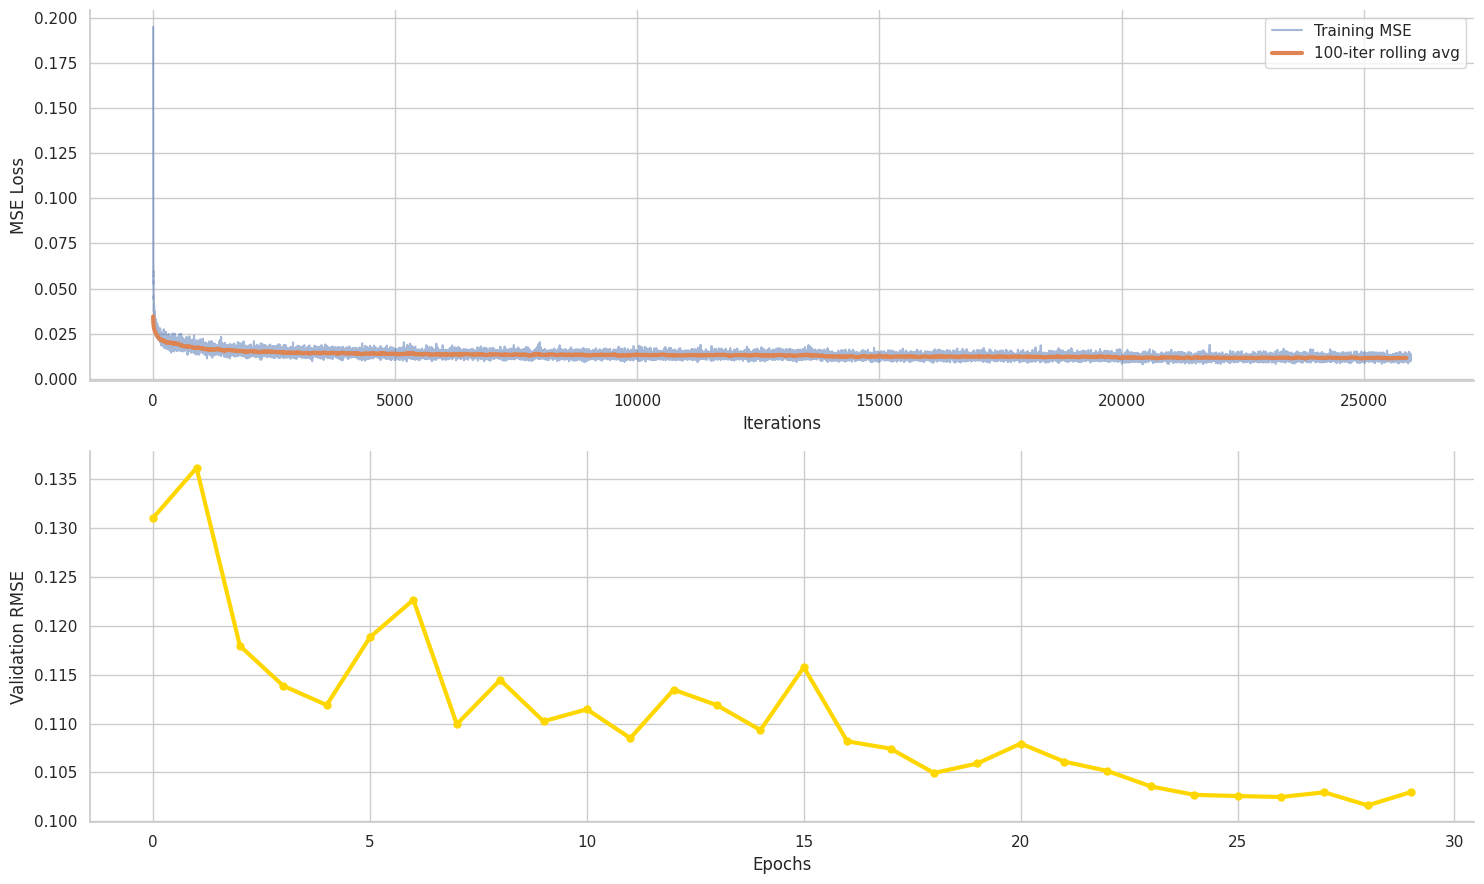

Final val RMSE : 0.10299
Best  val RMSE : 0.10162


In [12]:
# Configure plotting style for training metrics
import seaborn as sns
sns.set(style='whitegrid', font_scale=1)

# Create subplots for training loss and validation RMSE
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Plot training loss history
axes[0].plot(train_loss_list, linewidth=1.5, alpha=0.5, label='Training MSE')

# Plot rolling average to highlight overall training trend
if len(train_loss_list) >= 100:
    rolling_avg = np.convolve(train_loss_list, np.ones(100), 'valid') / 100
    axes[0].plot(rolling_avg, linewidth=3, label='100-iter rolling avg')

axes[0].set_ylabel('MSE Loss')
axes[0].set_xlabel('Iterations')
axes[0].legend()
sns.despine(ax=axes[0])

# Plot validation RMSE for each epoch
axes[1].plot(val_rmse_list, linewidth=3, color='gold', marker='o', markersize=5)
axes[1].set_ylabel('Validation RMSE')
axes[1].set_xlabel('Epochs')
sns.despine(ax=axes[1])

# Display training history plots
plt.tight_layout()
plt.show()

# Print final and best validation performance
print(f'Final val RMSE : {val_rmse_list[-1]:.5f}')
print(f'Best  val RMSE : {best_val_rmse:.5f}')

In [18]:
# Load the best saved model checkpoint
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Store predictions and true labels for validation set
all_preds  = []
all_labels = []

# Run model on validation data without updating gradients
with torch.no_grad():
    for X_val, y_val in val_loader:
        X_val = X_val.to(device)
        all_preds.append(model(X_val).cpu().numpy())
        all_labels.append(y_val.numpy())

# Combine batch outputs into full validation arrays
all_preds  = np.concatenate(all_preds,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Import evaluation utilities
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Question 1 classes
q1_cols = [0, 1, 2]

# Convert Question 1 probability labels into single class predictions
true_class = np.argmax(all_labels[:, q1_cols], axis=1)
pred_class = np.argmax(all_preds[:, q1_cols], axis=1)

# Compute confusion matrix
cm = confusion_matrix(true_class, pred_class)

# Compute ROC curves for selected classes
class_indices = [0, 1, 2, 6, 10]
roc_results = []

for class_idx in class_indices:
    y_true = (all_labels[:, class_idx] > 0.5).astype(int)
    y_score = all_preds[:, class_idx]

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    roc_results.append((class_idx, fpr, tpr, roc_auc))

# Compute RMSE values
col_rmse = np.sqrt(((all_preds - all_labels) ** 2).mean(axis=0))
overall_rmse = np.sqrt(((all_preds - all_labels) ** 2).mean())

# Find highest-error classes
num_remove = 5
worst_indices = np.argsort(col_rmse)[-num_remove:][::-1]
keep_indices = [i for i in range(len(label_columns)) if i not in worst_indices]

# Recompute RMSE after removing worst classes
reduced_rmse = np.sqrt(
    ((all_preds[:, keep_indices] - all_labels[:, keep_indices]) ** 2).mean()
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


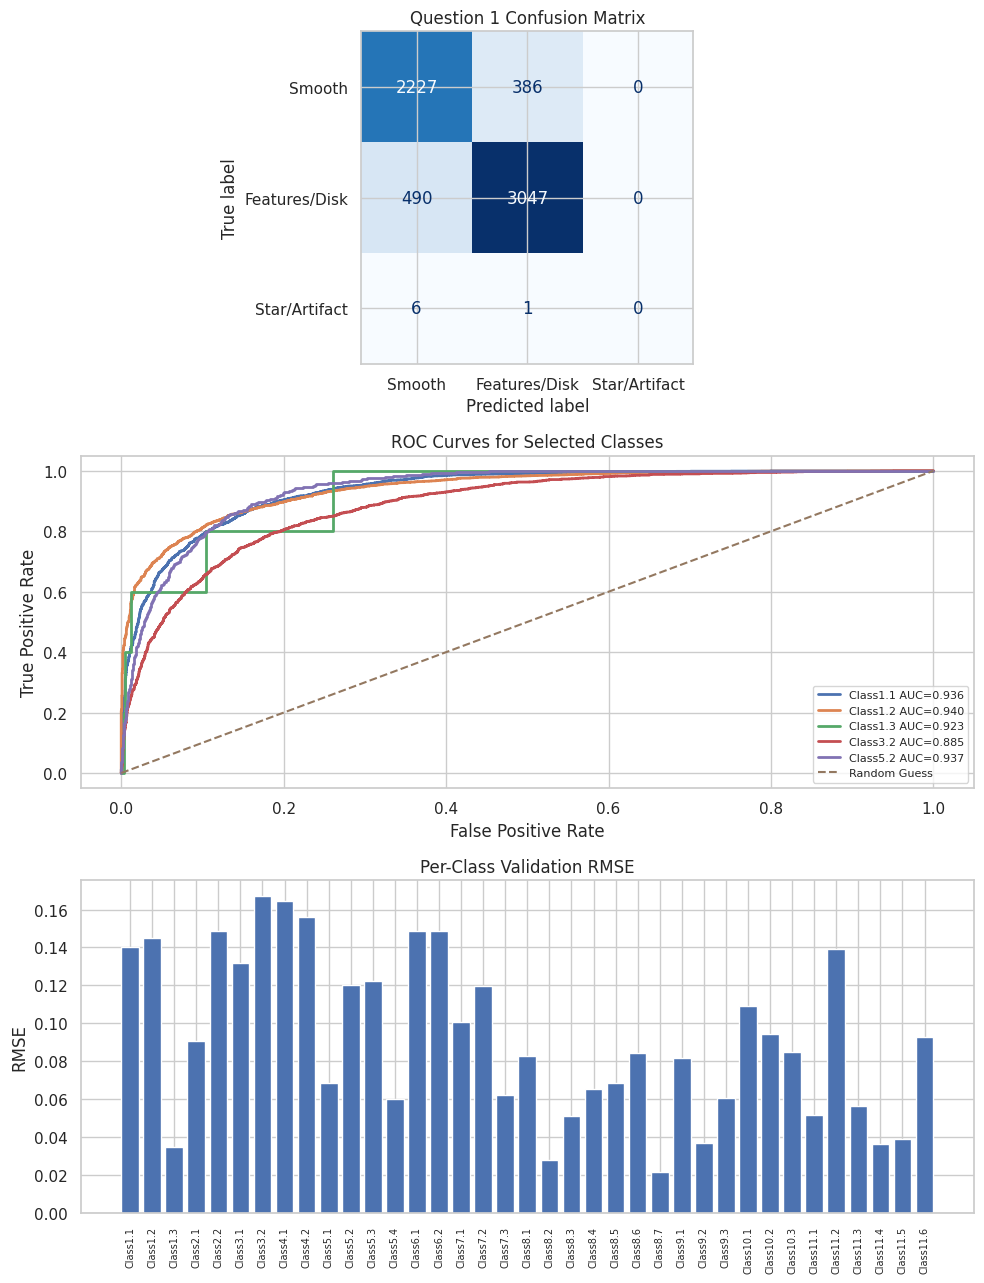

In [19]:
# Create one compact evaluation figure with all plots
fig = plt.figure(figsize=(10, 13))

# Confusion matrix plot
ax1 = fig.add_subplot(3, 1, 1)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Smooth", "Features/Disk", "Star/Artifact"]
)
disp.plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title("Question 1 Confusion Matrix")

# ROC plot
ax2 = fig.add_subplot(3, 1, 2)

for class_idx, fpr, tpr, roc_auc in roc_results:
    ax2.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{label_columns[class_idx]} AUC={roc_auc:.3f}'
    )

ax2.plot([0, 1], [0, 1], '--', label='Random Guess')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves for Selected Classes')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True)

# Per-class RMSE plot
ax3 = fig.add_subplot(3, 1, 3)
ax3.bar(range(len(label_columns)), col_rmse)
ax3.set_xticks(range(len(label_columns)))
ax3.set_xticklabels(label_columns, rotation=90, fontsize=7)
ax3.set_ylabel('RMSE')
ax3.set_title('Per-Class Validation RMSE')

plt.tight_layout()
plt.show()
plt.close()

In [20]:
# Print compact text summary instead of large tables
print("Evaluation Summary")
print(f"Best validation RMSE from training: {best_val_rmse:.5f}")
print(f"Overall validation RMSE from checkpoint: {overall_rmse:.5f}")
print(f"RMSE after removing worst {num_remove} classes: {reduced_rmse:.5f}")
print(f"RMSE improvement: {overall_rmse - reduced_rmse:.5f}")
print()
print("Highest-error classes:")
for idx in worst_indices:
    print(f"{label_columns[idx]:8s}  RMSE: {col_rmse[idx]:.5f}")

Evaluation Summary
Best validation RMSE from training: 0.10162
Overall validation RMSE from checkpoint: 0.10162
RMSE after removing worst 5 classes: 0.08985
RMSE improvement: 0.01176

Highest-error classes:
Class3.2  RMSE: 0.16713
Class4.1  RMSE: 0.16452
Class4.2  RMSE: 0.15615
Class6.2  RMSE: 0.14887
Class6.1  RMSE: 0.14887


## Generate Submission

**Requirements:**
- Run inference on all test images (no ground-truth labels available)
- Output CSV format: `GalaxyID, Class1.1, Class1.2, ..., Class11.6` (38 columns total)
- Output file: `submission.csv` in the `final_project/` directory
- Upload to [Kaggle submission page](https://www.kaggle.com/c/galaxy-zoo-the-galaxy-challenge/submit) for RMSE evaluation on the private leaderboard

In [21]:
# Create dataloader for Kaggle test dataset
test_loader = DataLoader(
    test_dataset,
    batch_size=batchsize,
    shuffle=False,
    num_workers=4,
    pin_memory=pin
)

# Set model to evaluation mode
model.eval()

# Store galaxy IDs and model predictions
test_galaxy_ids = []
test_predictions = []

# Generate predictions for all test images
with torch.no_grad():
    for X_test, galaxy_ids in test_loader:
        X_test = X_test.to(device)

        # Run forward pass and move predictions to CPU
        preds = model(X_test).cpu().numpy()

        test_predictions.append(preds)
        test_galaxy_ids.extend(galaxy_ids.tolist())

# Combine prediction batches into a single array
test_predictions = np.concatenate(test_predictions, axis=0)

# Create Kaggle submission dataframe
submission_df = pd.DataFrame(test_predictions, columns=label_columns)
submission_df.insert(0, 'GalaxyID', test_galaxy_ids)

# Save predictions in submission format
submission_df.to_csv('submission.csv', index=False)

# Display submission summary and preview
print(f'Saved submission.csv  ({len(submission_df)} rows x {len(label_columns)} outputs)')
display(submission_df.head())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Saved submission.csv  (79975 rows x 37 outputs)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100018,0.519999,0.468996,0.010195,0.026099,0.437126,0.059205,0.366987,0.128429,0.295956,...,0.006135,0.075397,0.032749,0.007299,0.006841,0.029623,0.004555,0.004554,0.004746,0.078919
1,100037,0.427801,0.551924,0.017323,0.379585,0.172867,0.023650,0.164671,0.052830,0.128269,...,0.222296,0.023867,0.021222,0.015072,0.008744,0.017845,0.005527,0.006698,0.007104,0.033403
2,100042,0.453218,0.529967,0.010119,0.347097,0.152695,0.017030,0.148416,0.039634,0.118306,...,0.160097,0.018751,0.013923,0.008275,0.004865,0.011668,0.002907,0.003648,0.003957,0.026256
3,100052,0.562243,0.413982,0.028336,0.006648,0.416642,0.051064,0.373530,0.129486,0.285080,...,0.001831,0.084931,0.037662,0.007082,0.012832,0.026804,0.009842,0.008086,0.007945,0.073007
4,100056,0.188714,0.798313,0.006313,0.732650,0.057337,0.011272,0.037903,0.020315,0.030408,...,0.345804,0.003509,0.007479,0.010194,0.002532,0.009259,0.001441,0.001874,0.001876,0.004680
